In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

C:\Users\JAIVAL CHAUHAN\anaconda3\envs\env-tf\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
train_dir = "data/adult/train"
val_dir = "data/adult/val"
test_dir = "data/adult/test"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


<h1>data preprocessing along with increasing the size of val set

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1   # 10% for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.


<h1>Model Building — DenseNet121

In [5]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load DenseNet121 with ImageNet weights, exclude top layers
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="swish")(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                              

In [6]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_densenet_model.h5", save_best_only=True)
]

<h1>training the model

In [7]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
146/146 [==============================] - 64s 379ms/step - loss: 0.4495 - accuracy: 0.7888 - val_loss: 0.3068 - val_accuracy: 0.8809
Epoch 2/15
146/146 [==============================] - 49s 338ms/step - loss: 0.3142 - accuracy: 0.8555 - val_loss: 0.2583 - val_accuracy: 0.8965
Epoch 3/15
146/146 [==============================] - 47s 323ms/step - loss: 0.2850 - accuracy: 0.8821 - val_loss: 0.2403 - val_accuracy: 0.8945
Epoch 4/15
146/146 [==============================] - 47s 324ms/step - loss: 0.2625 - accuracy: 0.8889 - val_loss: 0.2274 - val_accuracy: 0.9023
Epoch 5/15
146/146 [==============================] - 47s 323ms/step - loss: 0.2364 - accuracy: 0.9056 - val_loss: 0.2114 - val_accuracy: 0.9062
Epoch 6/15
146/146 [==============================] - 47s 324ms/step - loss: 0.2327 - accuracy: 0.9082 - val_loss: 0.2059 - val_accuracy: 0.9062
Epoch 7/15
146/146 [==============================] - 48s 330ms/step - loss: 0.2292 - accuracy: 0.9022 - val_loss: 0.1967 - val_ac

<h1>for testing dataset

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "data/adult/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# loss, accuracy = model.evaluate(test_generator)
# best_model = load_model("best_densenet_model.h5")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Found 624 images belonging to 2 classes.
20/20 [==============================] - 3s 123ms/step - loss: 0.2579 - accuracy: 0.9054
Test Loss: 0.2579
Test Accuracy: 90.54%


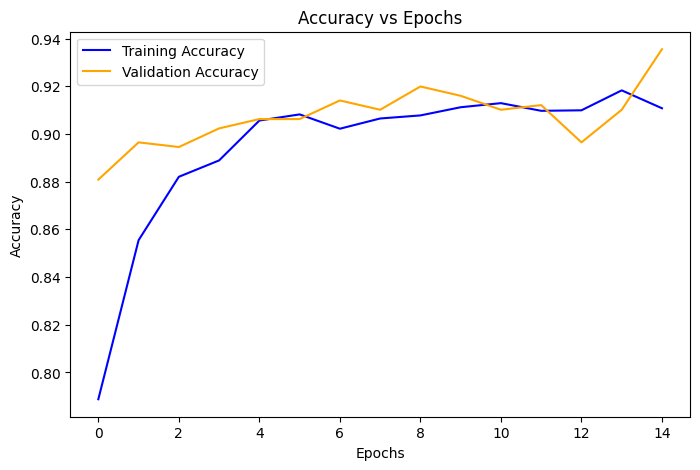

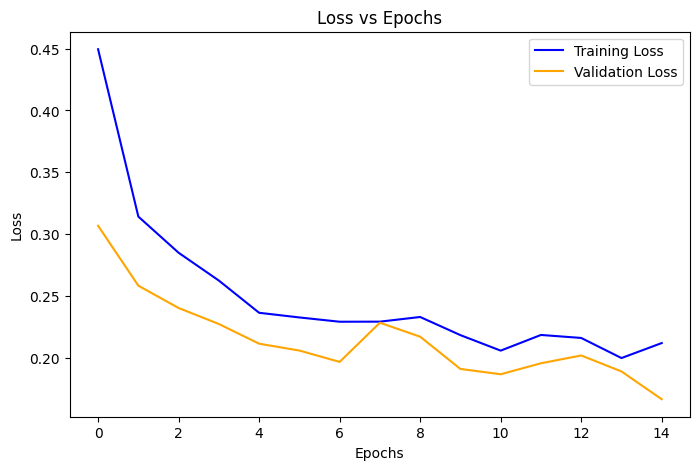

In [9]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h1>unfreezing the last 40 layers

In [10]:
# Unfreeze the last 40 layers of DenseNet121
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Compile with a lower learning rate
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-5), loss="binary_crossentropy", metrics=["accuracy"])

In [11]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [14]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=25,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/25
146/146 [==============================] - ETA: 0s - loss: 0.2265 - accuracy: 0.9101
Epoch 1: val_loss improved from 0.18246 to 0.17035, saving model to best_model.keras
146/146 [==============================] - 55s 371ms/step - loss: 0.2265 - accuracy: 0.9101 - val_loss: 0.1703 - val_accuracy: 0.9297 - lr: 1.0000e-05
Epoch 2/25
146/146 [==============================] - ETA: 0s - loss: 0.1922 - accuracy: 0.9234
Epoch 2: val_loss did not improve from 0.17035
146/146 [==============================] - 51s 352ms/step - loss: 0.1922 - accuracy: 0.9234 - val_loss: 0.1704 - val_accuracy: 0.9277 - lr: 1.0000e-05
Epoch 3/25
146/146 [==============================] - ETA: 0s - loss: 0.1947 - accuracy: 0.9260
Epoch 3: val_loss improved from 0.17035 to 0.15588, saving model to best_model.keras
146/146 [==============================] - 50s 341ms/step - loss: 0.1947 - accuracy: 0.9260 - val_loss: 0.1559 - val_accuracy: 0.9316 - lr: 1.0000e-05
Epoch 4/25
146/146 [======================

In [57]:
from tensorflow.keras.models import load_model

# Load the best model automatically saved during training
best_model = load_model("best_model.keras")

In [58]:
loss, accuracy = best_model.evaluate(test_generator)
print(f"Final Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

20/20 [==============================] - 5s 167ms/step - loss: 0.2519 - accuracy: 0.9071
Final Test Loss: 0.2519
Final Test Accuracy: 90.71%


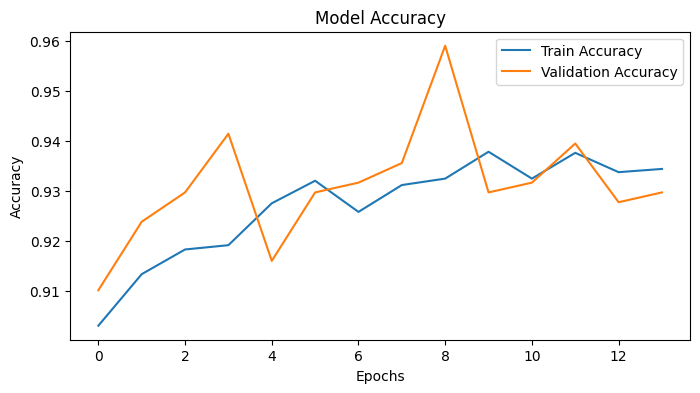

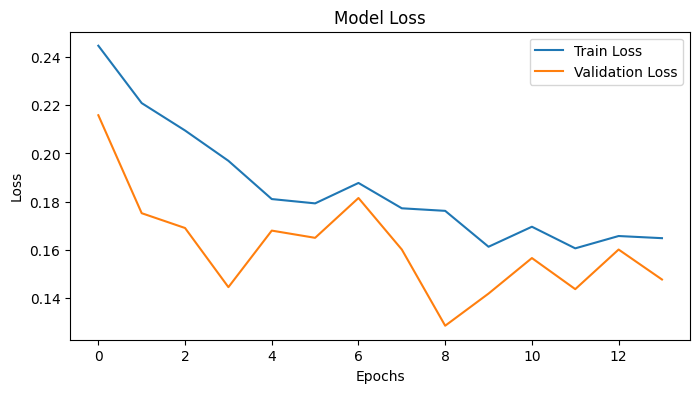

In [59]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()